15:46:21 - cmdstanpy - INFO - Chain [1] start processing
15:46:21 - cmdstanpy - INFO - Chain [1] done processing


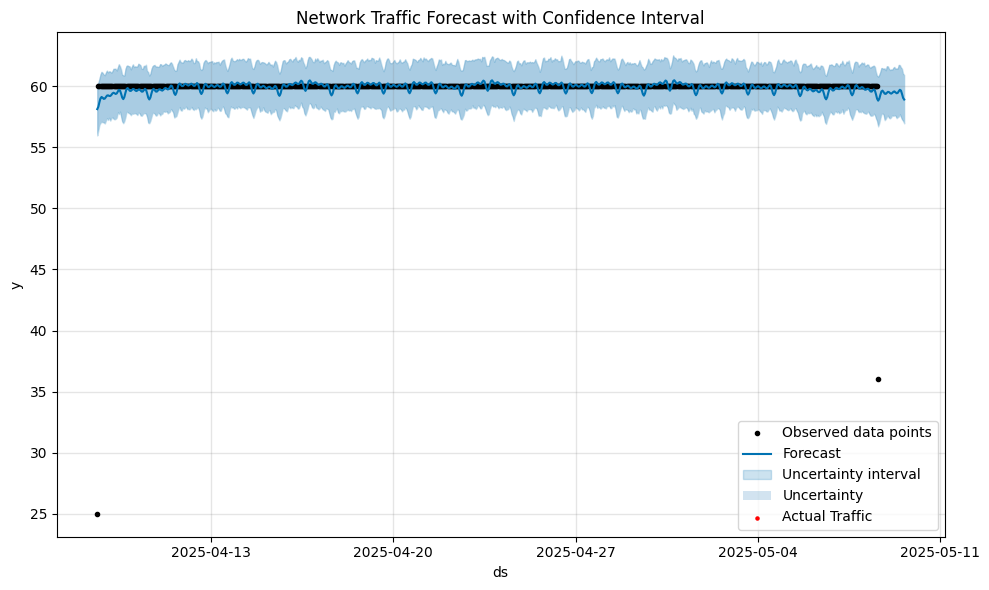

In [5]:
# %% [markdown]
# # 3. 网络拥塞预测
# 使用Prophet进行时间序列预测

# %%
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# %%
# 加载数据（新增这部分）
towers = pd.read_csv('../data/synthetic_towers.csv')
connections = pd.read_parquet('../data/synthetic_connections.parquet')

# %%
# 数据预处理（更新频率参数）
def prepare_ts_data(connections):
    hourly = connections.set_index('timestamp').resample('h').size()  # 小写 'h'
    return hourly.reset_index().rename(columns={'timestamp': 'ds', 0: 'y'})

# 建模预测
df = prepare_ts_data(connections)
model = Prophet(
    seasonality_mode='multiplicative',
    daily_seasonality=True,
    weekly_seasonality=True
)
model.fit(df)

future = model.make_future_dataframe(periods=24, freq='h')  # 小写 'h'
forecast = model.predict(future)

# 增强可视化
fig = model.plot(forecast)
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], alpha=0.2, label='Uncertainty')
plt.scatter(df['ds'], df['y'], s=5, c='red', label='Actual Traffic')
plt.title('Network Traffic Forecast with Confidence Interval')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/congestion_forecast.png')